# Step 3 — Exploratory Data Analysis: Descriptive Statistics

Walks through every sub-task in `src/features/eda.py` — no codebase changes, notebook only.

**Covers:**
1. Fare summaries by airline, source, destination, and seasonality
2. Correlation matrix among numerical features

> **Input:** `data/processed/Flight_Price_Dataset_of_Bangladesh.parquet` (output of Step 2 — Cleaning)

In [1]:
import sys
import logging
from pathlib import Path

ROOT = Path("../").resolve()
SRC  = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

logging.basicConfig(
    level=logging.INFO,
    format="%(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
    force=True,
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from utils.config import load_config
from features.eda import (
    load_processed,
    summarise_fares_by_group,
    correlation_matrix,
    plot_fare_distributions,
    plot_airline_boxplot,
    plot_avg_fare_by_time,
    plot_multicollinearity_heatmap,
    avg_fare_per_airline,
    most_popular_routes,
    seasonal_fare_variation,
    top_expensive_routes,
)

cfg            = load_config(ROOT / "configs" / "config.toml")
PROCESSED_PATH = ROOT / cfg["data"]["processed_path"]
RAW_PATH       = ROOT / cfg["data"]["raw_path"]
TARGET         = cfg["features"]["target"]
NUMERICAL_COLS = cfg["features"]["numerical"]
GROUP_COLS     = cfg["eda"]["group_cols"]
CORR_METHOD    = cfg["eda"]["correlation_method"]

sns.set_theme(style="whitegrid", palette="muted")
print("Setup complete. ROOT:", ROOT)

Setup complete. ROOT: /home/mbarndouka/Documents/amalitechmllab


In [2]:
df = load_processed(PROCESSED_PATH)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.dtypes

2026-05-12 19:20:32 [INFO] features.eda: Loaded processed data  shape=57000×19  path=/home/mbarndouka/Documents/amalitechmllab/data/processed/Flight_Price_Dataset_of_Bangladesh.parquet
Loaded processed data  shape=57000×19  path=/home/mbarndouka/Documents/amalitechmllab/data/processed/Flight_Price_Dataset_of_Bangladesh.parquet
Shape: 57,000 rows × 19 columns


airline                      str
source                       str
source_name                  str
destination                  str
destination_name             str
duration                 float64
stopovers                   int8
aircraft_type                str
travel_class                 str
booking_source               str
fare                     float64
seasonality                  str
days_left                  int64
departure_hour              int8
departure_day_of_week       int8
departure_month             int8
arrival_hour                int8
arrival_day_of_week         int8
arrival_month               int8
dtype: object

In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
airline,57000,24,US-Bangla Airlines,4496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source,57000,8,CGP,7241,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_name,57000,8,"Shah Amanat International Airport, Chittagong",7241,NaN,NaN,NaN,NaN,NaN,NaN,NaN
destination,57000,20,JED,3071,NaN,NaN,NaN,NaN,NaN,NaN,NaN
destination_name,57000,20,"King Abdulaziz International Airport, Jeddah",3071,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,57000.0,NaN,NaN,NaN,3.994955,4.094043,0.5,1.003745,2.644656,5.490104,15.831719
stopovers,57000.0,NaN,NaN,NaN,0.409053,0.587813,0.0,0.0,0.0,1.0,2.0
aircraft_type,57000,5,Airbus A320,23970,NaN,NaN,NaN,NaN,NaN,NaN,NaN
travel_class,57000,3,Economy,19112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_source,57000,3,Direct Booking,19111,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## Part 1 — Fare Summaries by Categorical Group

`summarise_fares_by_group()` computes per-group statistics:
`count`, `mean`, `median`, `std`, `p25`, `p75`, `min`, `max`, and `%vs_avg` (% above/below overall mean).

In [4]:
summaries = summarise_fares_by_group(df, GROUP_COLS, TARGET)

2026-05-12 19:20:51 [INFO] features.eda: === FARE SUMMARY BY AIRLINE ===
=== FARE SUMMARY BY AIRLINE ===
2026-05-12 19:20:51 [INFO] features.eda:   Group                           N        Mean      Median        Std         P25         P75         Min         Max   %vsAvg
  Group                           N        Mean      Median        Std         P25         P75         Min         Max   %vsAvg
2026-05-12 19:20:51 [INFO] features.eda:   -----------------------------------------------------------------------------------------------------------------------------
  -----------------------------------------------------------------------------------------------------------------------------
2026-05-12 19:20:51 [INFO] features.eda:   Turkish Airlines             2220    75547.27    43172.68   86133.38    10053.26   112483.89     1842.79   558987.33  +6.4%
  Turkish Airlines             2220    75547.27    43172.68   86133.38    10053.26   112483.89     1842.79   558987.33  +6.4%
2026-05-

### 1a. Fare by Airline

In [5]:
summaries["airline"]

,count,mean,median,std,p25,p75,min,max,pct_vs_avg
airline,,,,,,,,,
Turkish Airlines,2220,75547.27,43172.68,86133.38,10053.26,112483.89,1842.79,558987.33,6.4
AirAsia,2312,74534.39,42763.82,85962.63,9438.71,111325.26,1804.13,415248.03,4.9
Cathay Pacific,2282,73325.09,46282.46,83285.51,9663.97,106516.09,1805.89,419822.09,3.2
Thai Airways,2316,72845.79,42898.83,83424.34,9943.47,108148.74,1814.62,447814.56,2.6
Malaysian Airlines,2292,72775.18,41938.11,82382.28,9942.34,110696.34,1872.76,482855.60,2.5
IndiGo,2223,72504.43,42018.49,83581.70,9795.95,104162.67,1809.27,524278.76,2.1
Air India,2280,72474.18,42429.62,83772.26,9656.93,103057.77,1816.37,404646.53,2.0
US-Bangla Airlines,4496,72088.29,41255.33,82114.58,9874.58,106803.35,1801.20,437270.96,1.5
Kuwait Airways,2262,71988.28,39584.26,83430.85,9470.10,106670.43,1806.92,458420.04,1.3


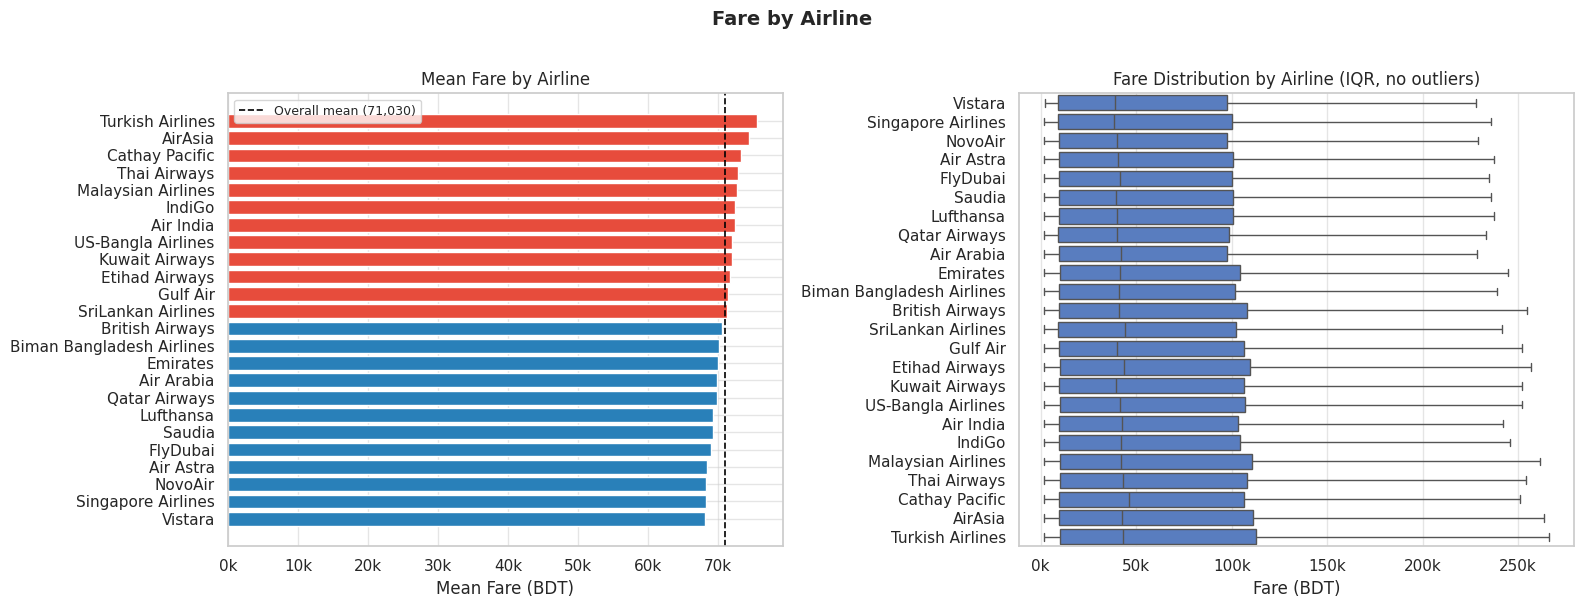

In [6]:
s_airline = summaries["airline"].sort_values("mean")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mean fare bar (colour-coded above/below overall mean)
overall_mean = df[TARGET].mean()
colors = ["#e74c3c" if v >= overall_mean else "#2980b9" for v in s_airline["mean"]]
bars = axes[0].barh(s_airline.index, s_airline["mean"], color=colors)
axes[0].axvline(overall_mean, color="black", linestyle="--", linewidth=1.2, label=f"Overall mean ({overall_mean:,.0f})")
axes[0].set_xlabel("Mean Fare (BDT)")
axes[0].set_title("Mean Fare by Airline")
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

# Box plot
order = s_airline.index.tolist()
sns.boxplot(
    data=df, y="airline", x=TARGET, order=order,
    ax=axes[1], showfliers=False, orient="h",
)
axes[1].set_xlabel("Fare (BDT)")
axes[1].set_ylabel("")
axes[1].set_title("Fare Distribution by Airline (IQR, no outliers)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

plt.suptitle("Fare by Airline", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 1b. Fare by Source Airport

In [7]:
summaries["source"]

,count,mean,median,std,p25,p75,min,max,pct_vs_avg
source,,,,,,,,,
BZL,7102,72679.11,43584.81,83073.38,9917.90,105611.90,1824.63,489089.92,2.3
ZYL,7179,71946.58,42643.37,82426.62,9916.21,104098.28,1801.20,558987.33,1.3
SPD,7043,71306.31,41149.84,81523.10,9742.82,105337.63,1812.39,546970.92,0.4
CXB,7049,71012.87,41133.57,81382.15,9422.31,104190.51,1804.13,479213.62,-0.0
CGP,7241,70877.63,40416.26,82236.61,9566.20,103504.13,1809.27,524278.76,-0.2
RJH,7091,70532.91,39743.69,82069.23,9368.29,103572.14,1800.98,522606.37,-0.7
DAC,7146,70349.71,40935.91,81107.22,9505.38,103579.93,1805.89,466709.75,-1.0
JSR,7149,69545.90,40820.00,80296.04,9519.30,101228.75,1808.64,473812.80,-2.1


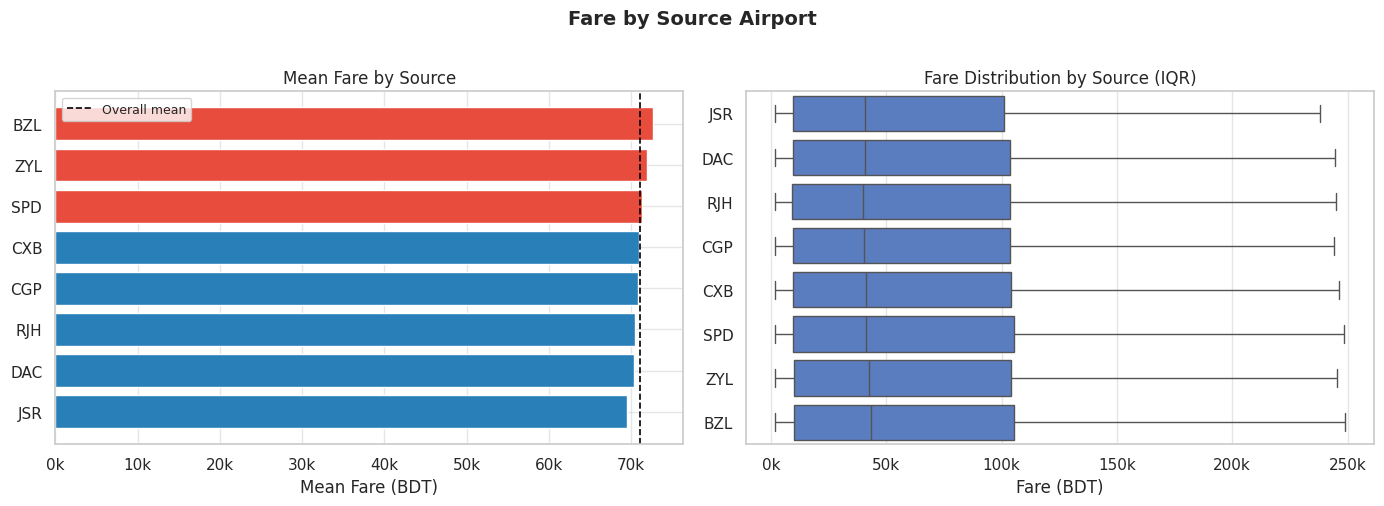

In [8]:
s_source = summaries["source"].sort_values("mean")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#e74c3c" if v >= overall_mean else "#2980b9" for v in s_source["mean"]]
axes[0].barh(s_source.index, s_source["mean"], color=colors)
axes[0].axvline(overall_mean, color="black", linestyle="--", linewidth=1.2, label=f"Overall mean")
axes[0].set_xlabel("Mean Fare (BDT)")
axes[0].set_title("Mean Fare by Source")
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

sns.boxplot(
    data=df, y="source", x=TARGET, order=s_source.index.tolist(),
    ax=axes[1], showfliers=False, orient="h",
)
axes[1].set_xlabel("Fare (BDT)")
axes[1].set_ylabel("")
axes[1].set_title("Fare Distribution by Source (IQR)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

plt.suptitle("Fare by Source Airport", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 1c. Fare by Destination Airport

In [9]:
summaries["destination"]

,count,mean,median,std,p25,p75,min,max,pct_vs_avg
destination,,,,,,,,,
JFK,3066,110903.06,80075.97,84928.44,48536.96,151272.28,10995.47,522606.37,56.1
KUL,2968,110495.41,81756.25,82321.29,49634.71,149319.53,10825.58,460399.22,55.6
LHR,2968,109562.06,79722.05,84181.26,47174.59,148239.56,10860.27,546970.92,54.2
YYZ,2921,109530.89,80418.69,82693.45,46510.94,149988.84,11319.42,493383.97,54.2
DXB,3005,109374.48,79052.73,84689.61,46922.20,148955.05,8813.64,489089.92,54.0
SIN,3063,109085.96,79234.28,83916.29,46011.80,148498.31,10886.56,479213.62,53.6
BKK,3036,107971.30,79582.96,80852.07,48021.98,147050.02,10767.18,405746.39,52.0
JED,3071,107731.56,81748.43,80846.08,46973.96,145885.92,8723.43,472869.99,51.7
DOH,2923,107011.91,79583.13,81769.37,46365.52,145003.05,8717.07,473812.80,50.7


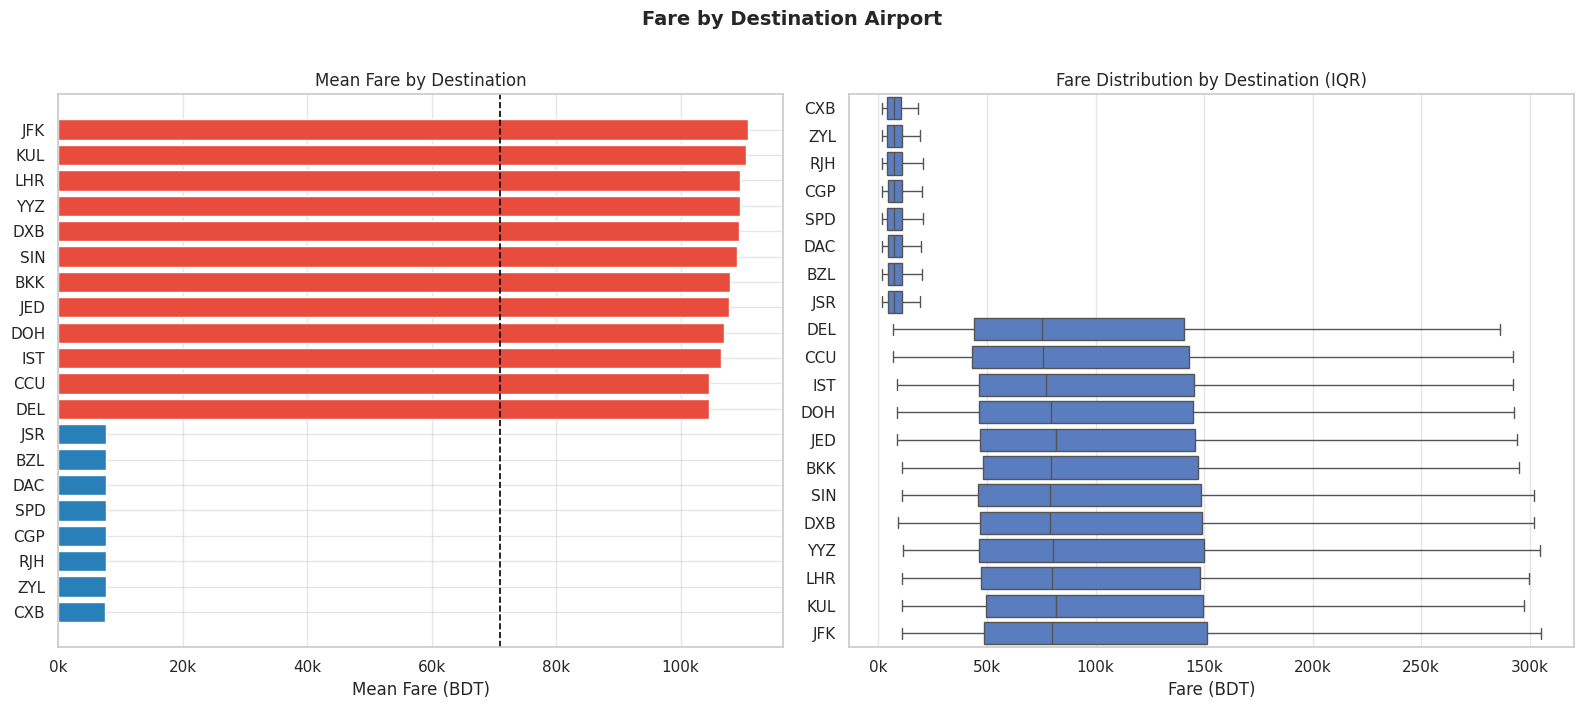

In [10]:
s_dest = summaries["destination"].sort_values("mean")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors = ["#e74c3c" if v >= overall_mean else "#2980b9" for v in s_dest["mean"]]
axes[0].barh(s_dest.index, s_dest["mean"], color=colors)
axes[0].axvline(overall_mean, color="black", linestyle="--", linewidth=1.2)
axes[0].set_xlabel("Mean Fare (BDT)")
axes[0].set_title("Mean Fare by Destination")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

sns.boxplot(
    data=df, y="destination", x=TARGET, order=s_dest.index.tolist(),
    ax=axes[1], showfliers=False, orient="h",
)
axes[1].set_xlabel("Fare (BDT)")
axes[1].set_ylabel("")
axes[1].set_title("Fare Distribution by Destination (IQR)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

plt.suptitle("Fare by Destination Airport", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 1d. Fare by Seasonality

In [11]:
summaries["seasonality"]

,count,mean,median,std,p25,p75,min,max,pct_vs_avg
seasonality,,,,,,,,,
Hajj,942,97144.47,54250.27,113236.76,12931.23,149780.24,2682.58,558987.33,36.8
Eid,603,91560.02,56621.23,101038.76,13630.67,127769.05,2291.60,524278.76,28.9
Winter Holidays,10930,79676.74,47272.62,90677.97,10849.75,117074.61,2120.46,493383.97,12.2
Regular,44525,68077.27,39898.22,78006.55,9269.53,99577.37,1800.98,420558.93,-4.2


/tmp/ipykernel_89647/1543974035.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha="right")


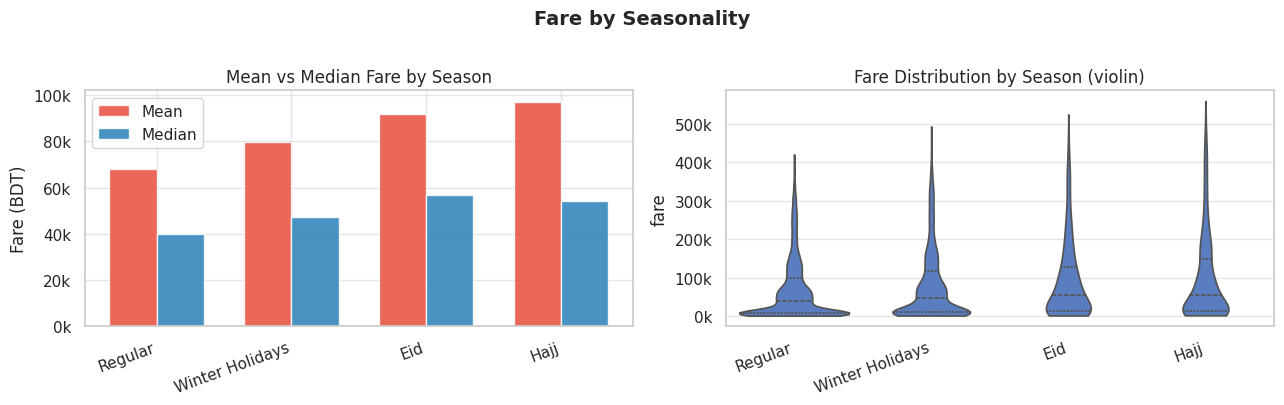

In [12]:
s_season = summaries["seasonality"].sort_values("mean")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Mean + median bars side by side
x = range(len(s_season))
width = 0.35
axes[0].bar([xi - width/2 for xi in x], s_season["mean"],   width, label="Mean",   color="#e74c3c", alpha=0.85)
axes[0].bar([xi + width/2 for xi in x], s_season["median"], width, label="Median", color="#2980b9", alpha=0.85)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(s_season.index, rotation=20, ha="right")
axes[0].set_ylabel("Fare (BDT)")
axes[0].set_title("Mean vs Median Fare by Season")
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y/1000:.0f}k"))

# Violin plot
order = s_season.index.tolist()
sns.violinplot(
    data=df, x="seasonality", y=TARGET, order=order,
    ax=axes[1], inner="quartile", cut=0,
)
axes[1].set_xlabel("")
axes[1].set_title("Fare Distribution by Season (violin)")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha="right")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y/1000:.0f}k"))

plt.suptitle("Fare by Seasonality", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 1e. Pct-vs-average summary (all groups)

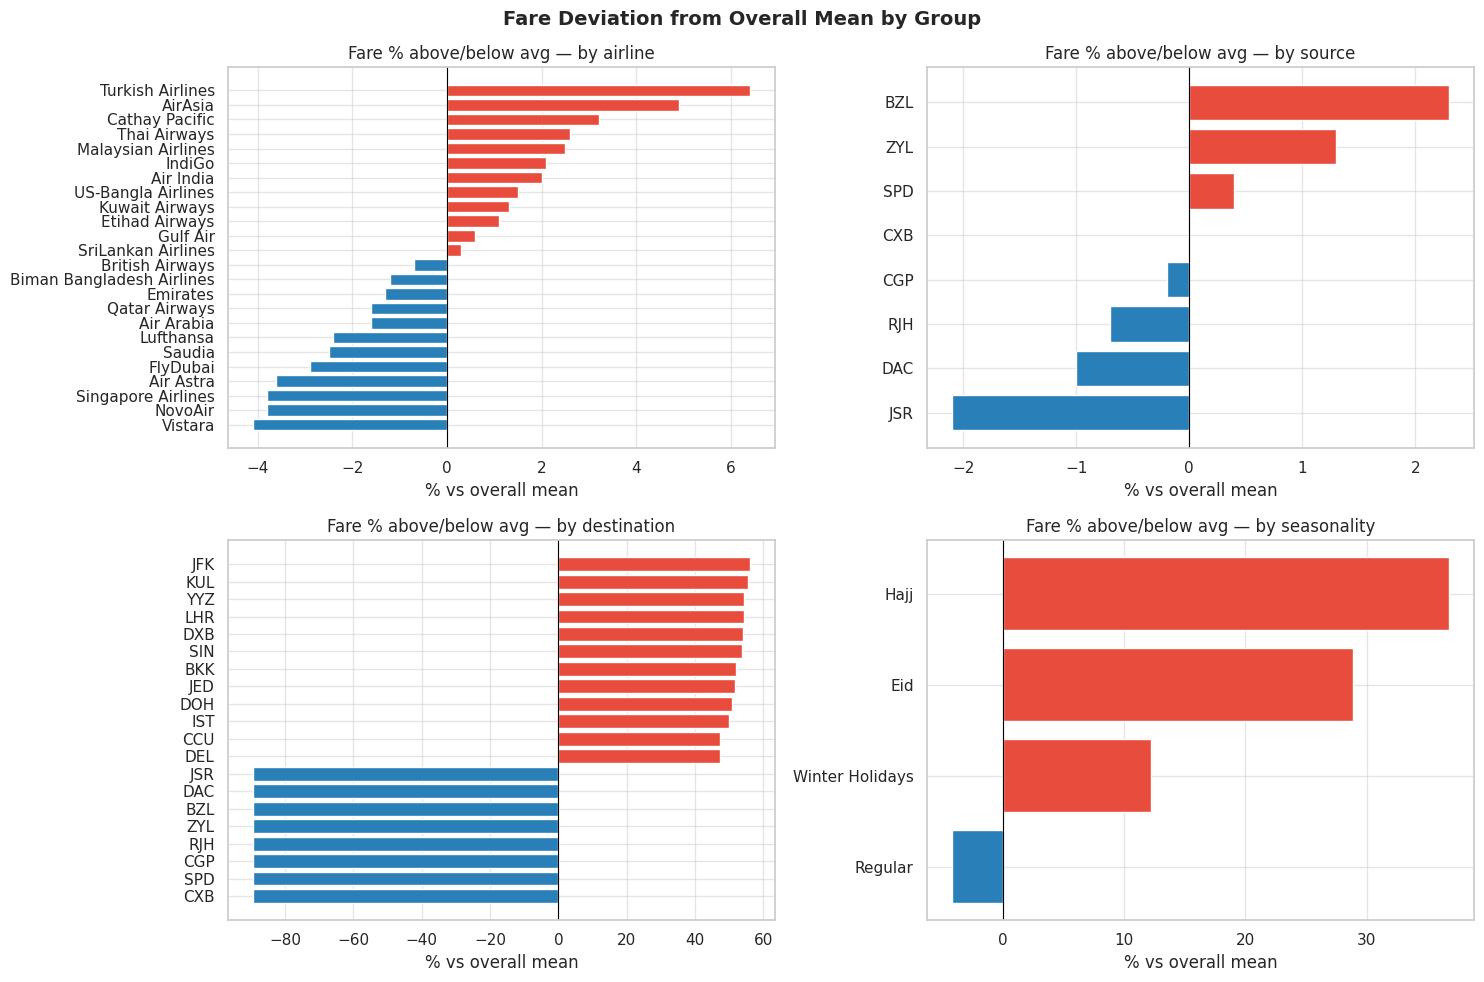

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for ax, col in zip(axes, GROUP_COLS):
    s = summaries[col].sort_values("pct_vs_avg")
    colors = ["#e74c3c" if v >= 0 else "#2980b9" for v in s["pct_vs_avg"]]
    ax.barh(s.index, s["pct_vs_avg"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("% vs overall mean")
    ax.set_title(f"Fare % above/below avg — by {col}")

plt.suptitle("Fare Deviation from Overall Mean by Group", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Part 2 — Correlation Analysis

`correlation_matrix()` computes pairwise Pearson correlations for all numerical features and the target.
Features are then ranked by |r| with the target to surface the strongest predictors.

In [14]:
corr = correlation_matrix(df, NUMERICAL_COLS, TARGET, method=CORR_METHOD)

2026-05-12 19:25:06 [INFO] features.eda: === CORRELATION MATRIX (PEARSON) — 10 features ===
=== CORRELATION MATRIX (PEARSON) — 10 features ===
2026-05-12 19:25:06 [INFO] features.eda: 
                       duration  days_left  stopovers  departure_hour  departure_day_of_week  departure_month  arrival_hour  arrival_day_of_week  arrival_month   fare
duration                  1.000      0.001      0.736          -0.002                  0.000           -0.005         0.002               -0.002         -0.005  0.351
days_left                 0.001      1.000      0.004           0.000                 -0.002            0.004        -0.001               -0.004          0.004 -0.079
stopovers                 0.736      0.004      1.000          -0.001                 -0.000           -0.003         0.002               -0.001         -0.003  0.318
departure_hour           -0.002      0.000     -0.001           1.000                  0.002            0.000         0.346                0.003   

In [15]:
corr

,duration,days_left,stopovers,departure_hour,departure_day_of_week,departure_month,arrival_hour,arrival_day_of_week,arrival_month,fare
duration,1.000,0.001,0.736,-0.002,0.000,-0.005,0.002,-0.002,-0.005,0.351
days_left,0.001,1.000,0.004,0.000,-0.002,0.004,-0.001,-0.004,0.004,-0.079
stopovers,0.736,0.004,1.000,-0.001,-0.000,-0.003,0.002,-0.001,-0.003,0.318
departure_hour,-0.002,0.000,-0.001,1.000,0.002,0.000,0.346,0.003,-0.000,-0.005
departure_day_of_week,0.000,-0.002,-0.000,0.002,1.000,-0.010,0.002,0.875,-0.009,0.001
departure_month,-0.005,0.004,-0.003,0.000,-0.010,1.000,0.002,-0.011,0.997,-0.008
arrival_hour,0.002,-0.001,0.002,0.346,0.002,0.002,1.000,0.002,0.002,0.000
arrival_day_of_week,-0.002,-0.004,-0.001,0.003,0.875,-0.011,0.002,1.000,-0.011,0.001
arrival_month,-0.005,0.004,-0.003,-0.000,-0.009,0.997,0.002,-0.011,1.000,-0.010
fare,0.351,-0.079,0.318,-0.005,0.001,-0.008,0.000,0.001,-0.010,1.000


### 2a. Full correlation heatmap

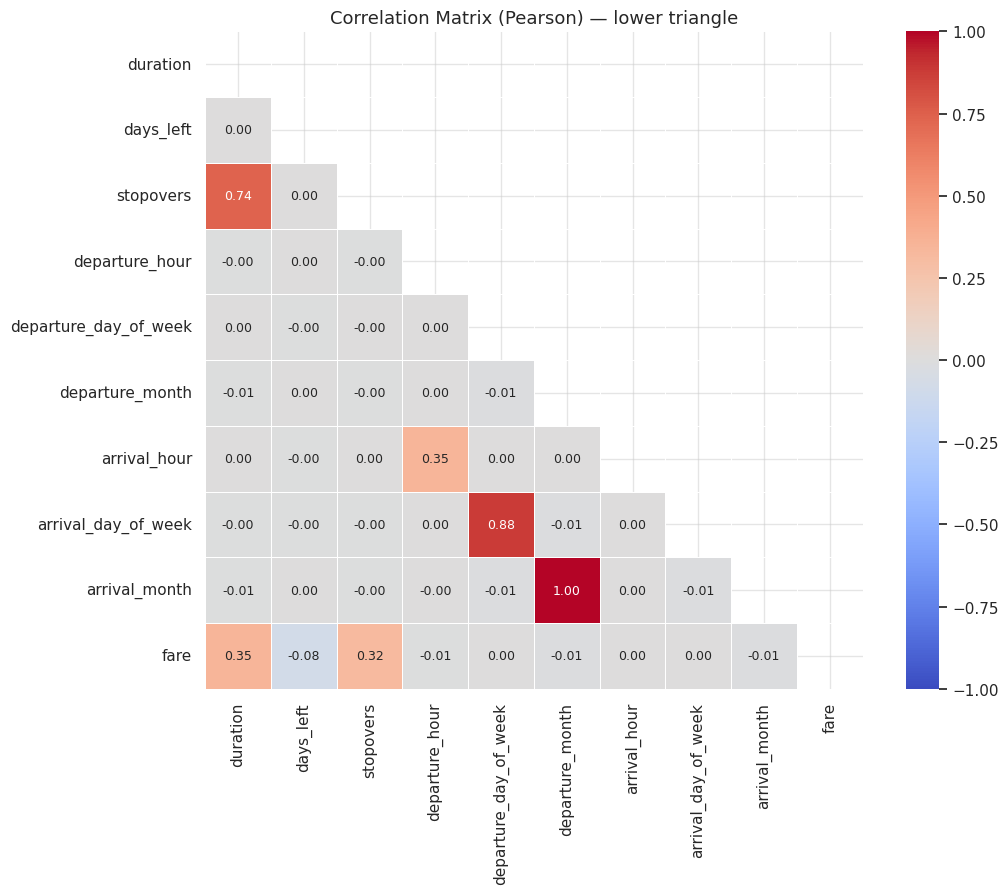

In [16]:
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.4,
    square=True,
    ax=ax,
    annot_kws={"size": 9},
)
ax.set_title(f"Correlation Matrix ({CORR_METHOD.capitalize()}) — lower triangle", fontsize=13)
plt.tight_layout()
plt.show()

### 2b. Feature → target correlation (ranked bar chart)

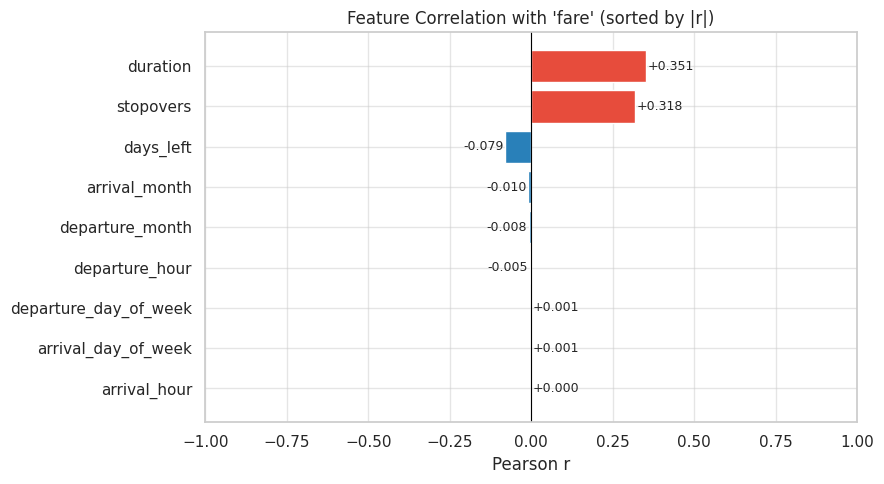

In [17]:
target_corr = (
    corr[TARGET]
    .drop(TARGET, errors="ignore")
    .sort_values(key=abs, ascending=False)
)

colors = ["#e74c3c" if v >= 0 else "#2980b9" for v in target_corr]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(target_corr.index[::-1], target_corr.values[::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel(f"{CORR_METHOD.capitalize()} r")
ax.set_title(f"Feature Correlation with '{TARGET}' (sorted by |r|)")
for i, (feat, r) in enumerate(zip(target_corr.index[::-1], target_corr.values[::-1])):
    ax.text(r + (0.005 if r >= 0 else -0.005), i, f"{r:+.3f}",
            va="center", ha="left" if r >= 0 else "right", fontsize=9)
ax.set_xlim(-1, 1)
plt.tight_layout()
plt.show()

### 2c. Scatter matrix — top correlated features vs target

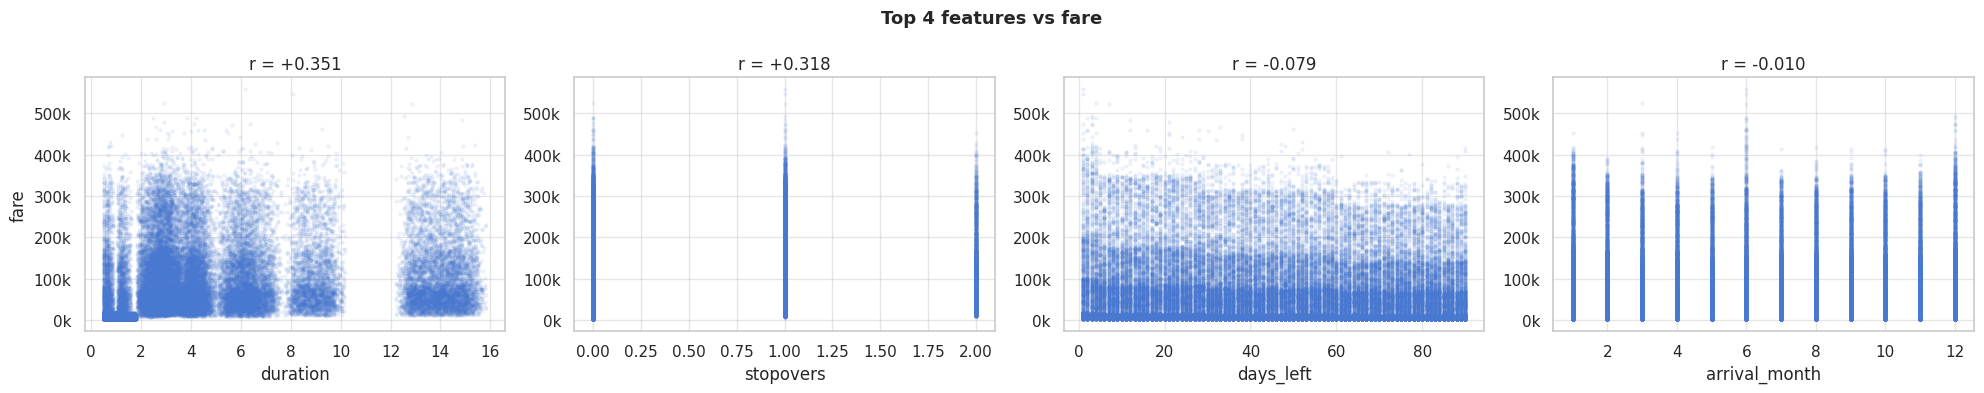

In [18]:
TOP_N = 4
top_features = target_corr.head(TOP_N).index.tolist()

fig, axes = plt.subplots(1, TOP_N, figsize=(5 * TOP_N, 4))
for ax, feat in zip(axes, top_features):
    ax.scatter(df[feat], df[TARGET], alpha=0.07, s=5, rasterized=True)
    r = target_corr[feat]
    ax.set_xlabel(feat)
    ax.set_ylabel(TARGET if feat == top_features[0] else "")
    ax.set_title(f"r = {r:+.3f}")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y/1000:.0f}k"))

plt.suptitle(f"Top {TOP_N} features vs {TARGET}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 2d. Spearman correlation (ordinal-aware)

In [19]:
corr_spearman = correlation_matrix(df, NUMERICAL_COLS, TARGET, method="spearman")

2026-05-12 19:26:19 [INFO] features.eda: === CORRELATION MATRIX (SPEARMAN) — 10 features ===
=== CORRELATION MATRIX (SPEARMAN) — 10 features ===
2026-05-12 19:26:19 [INFO] features.eda: 
                       duration  days_left  stopovers  departure_hour  departure_day_of_week  departure_month  arrival_hour  arrival_day_of_week  arrival_month   fare
duration                  1.000      0.001      0.756          -0.004                  0.001           -0.005         0.000               -0.000         -0.005  0.649
days_left                 0.001      1.000      0.004           0.000                 -0.002            0.004        -0.001               -0.004          0.004 -0.066
stopovers                 0.756      0.004      1.000          -0.002                 -0.000           -0.004        -0.000               -0.001         -0.004  0.469
departure_hour           -0.004      0.000     -0.002           1.000                  0.002            0.000         0.345                0.003 

In [20]:
# Compare Pearson vs Spearman for target correlations
pearson_t  = corr[TARGET].drop(TARGET, errors="ignore").rename("pearson")
spearman_t = corr_spearman[TARGET].drop(TARGET, errors="ignore").rename("spearman")
comparison = pd.concat([pearson_t, spearman_t], axis=1).sort_values("pearson", key=abs, ascending=False)

comparison["delta"] = (comparison["spearman"] - comparison["pearson"]).round(3)
comparison

,pearson,spearman,delta
duration,0.351,0.649,0.298
stopovers,0.318,0.469,0.151
days_left,-0.079,-0.066,0.013
arrival_month,-0.010,-0.008,0.002
departure_month,-0.008,-0.007,0.001
departure_hour,-0.005,-0.004,0.001
departure_day_of_week,0.001,0.002,0.001
arrival_day_of_week,0.001,0.001,0.000
arrival_hour,0.000,-0.000,-0.000


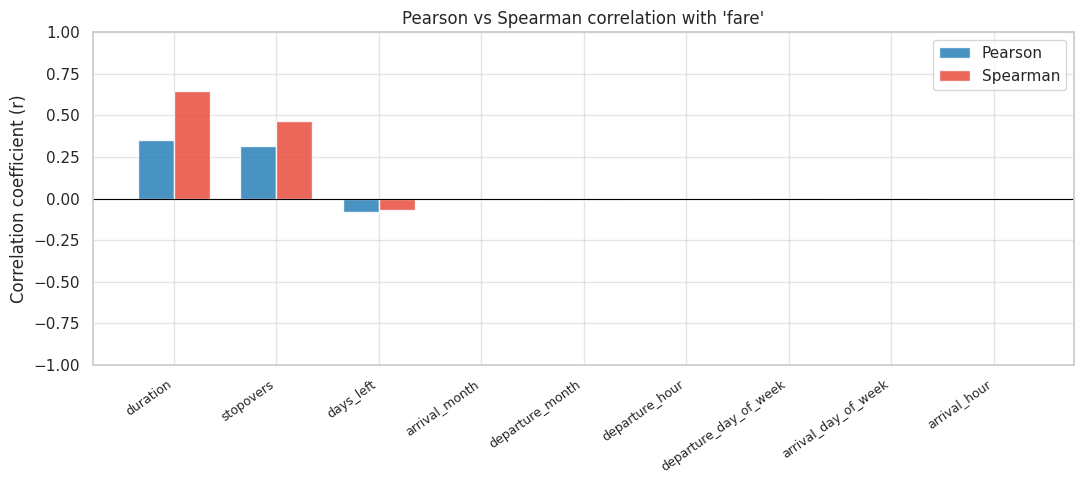

In [21]:
x_pos    = range(len(comparison))
width    = 0.35
features = comparison.index.tolist()

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar([xi - width/2 for xi in x_pos], comparison["pearson"],  width, label="Pearson",  color="#2980b9", alpha=0.85)
ax.bar([xi + width/2 for xi in x_pos], comparison["spearman"], width, label="Spearman", color="#e74c3c", alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(list(x_pos))
ax.set_xticklabels(features, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Correlation coefficient (r)")
ax.set_title(f"Pearson vs Spearman correlation with '{TARGET}'")
ax.legend()
ax.set_ylim(-1, 1)
plt.tight_layout()
plt.show()

---
## Part 3 — Visual Analysis

Fare, base fare, and tax distributions; airline boxplots; average fare by month and season; multicollinearity heatmap.

### 3a. Distributions — Total Fare, Base Fare, Tax & Surcharge

Base Fare and Tax were dropped from processed data (leakage prevention). Loaded from raw CSV here for visual inspection only.

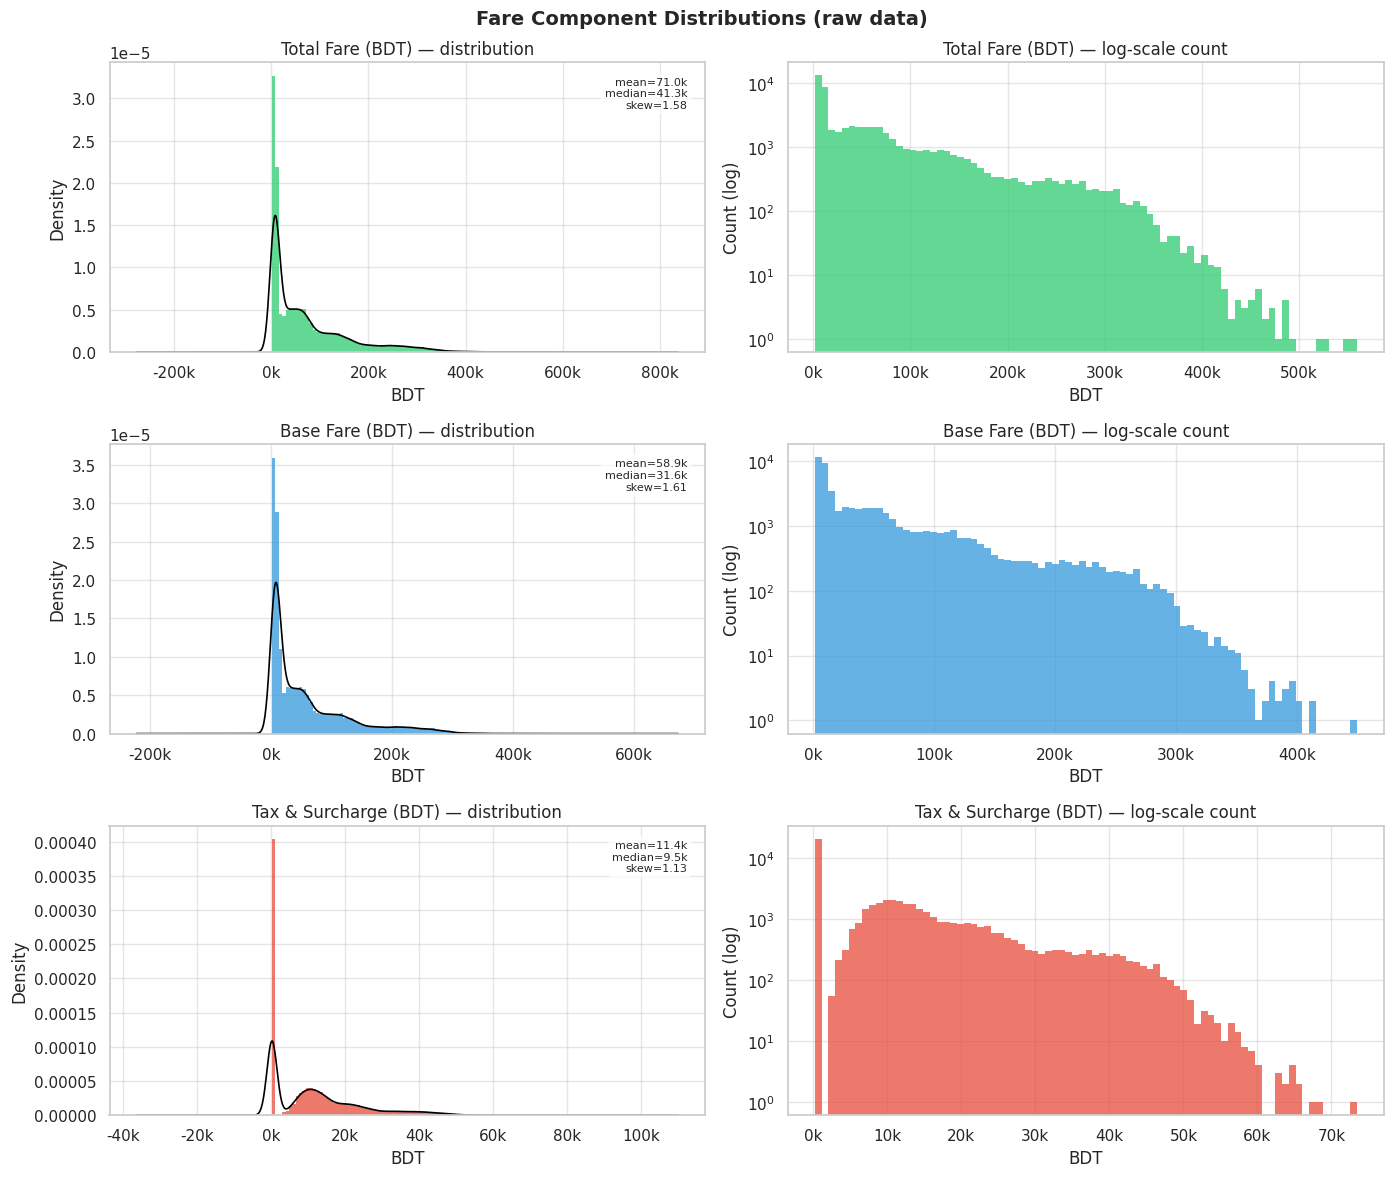

In [22]:
plot_fare_distributions(RAW_PATH)

### 3b. Boxplots — Fare Variation Across Airlines

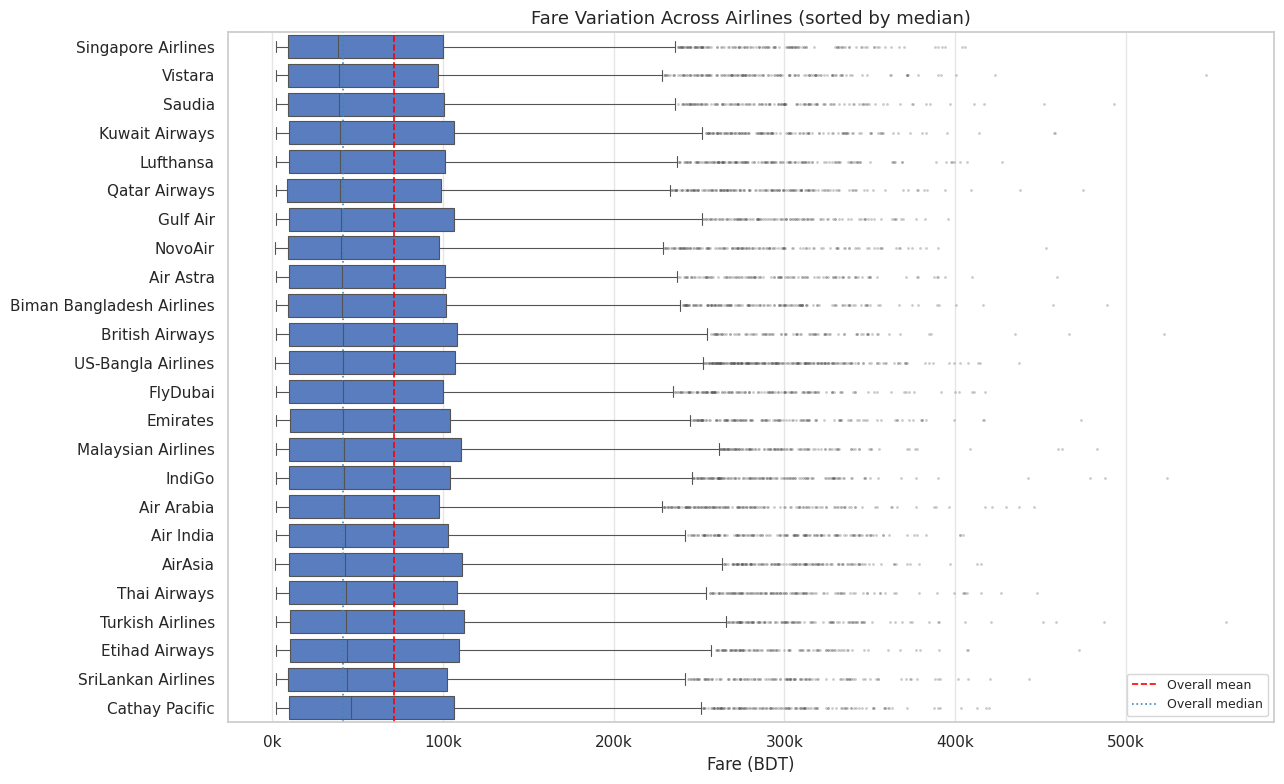

In [23]:
plot_airline_boxplot(df, target=TARGET)

### 3c. Average Fare by Month and Season

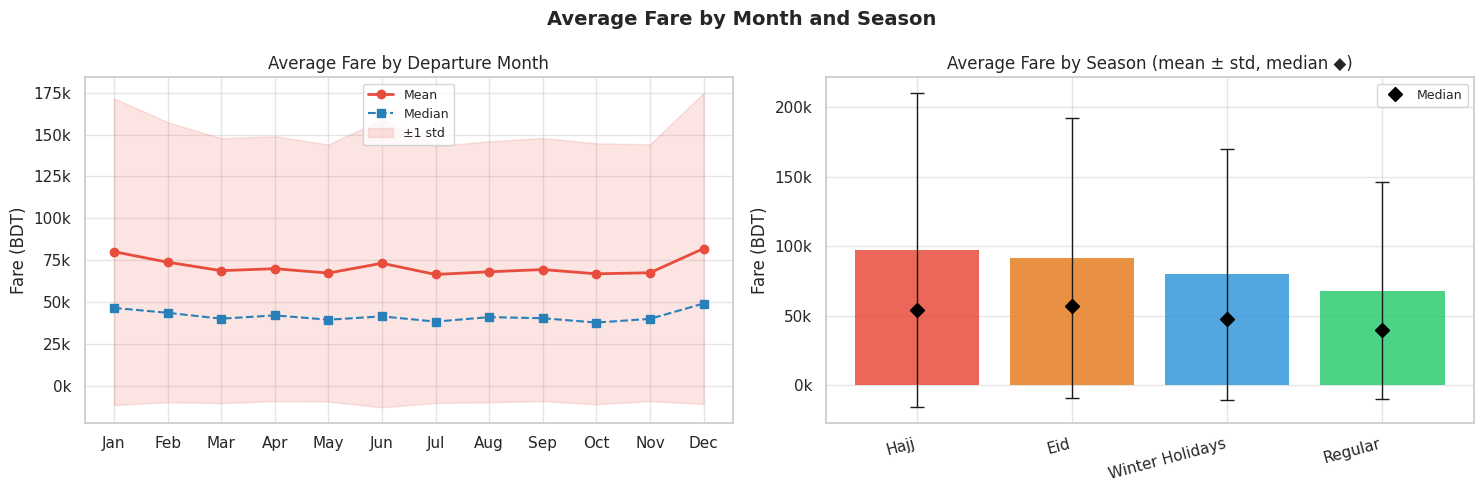

In [24]:
plot_avg_fare_by_time(df, target=TARGET)

### 3d. Multicollinearity Heatmap — Feature–Feature Correlations

Target excluded. Pairs with |r| > 0.7 flagged as multicollinearity concerns.

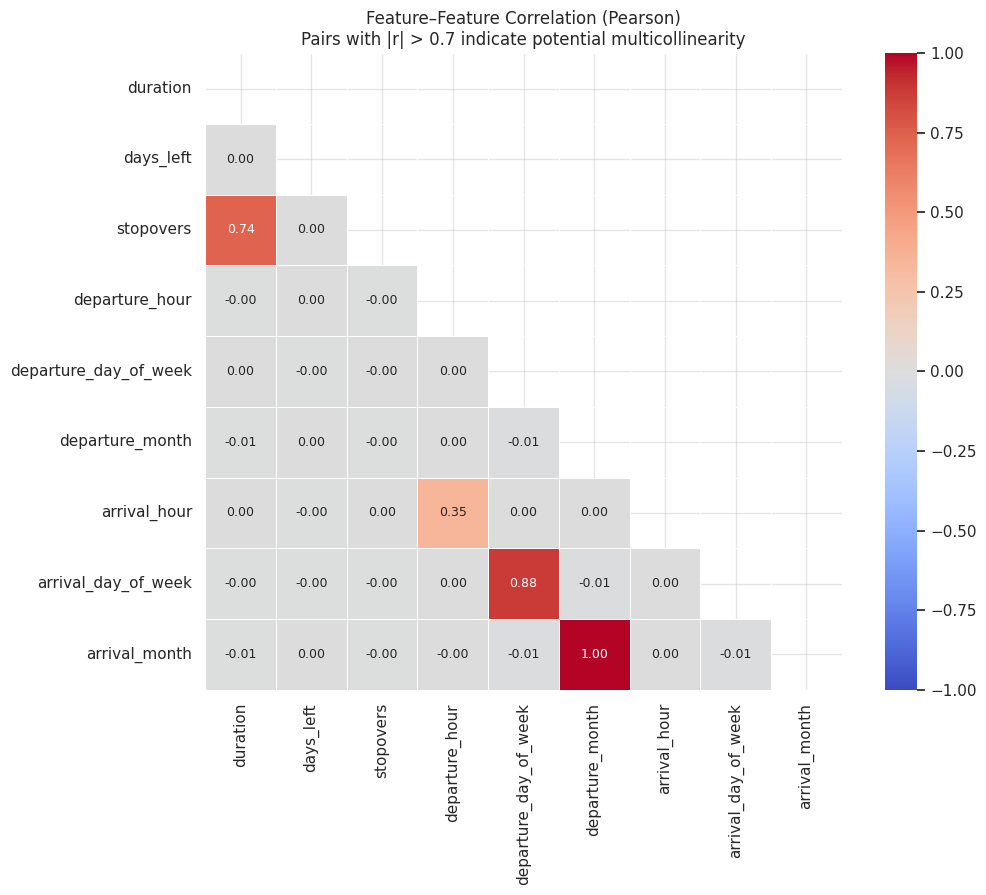

2026-05-12 19:29:12 [INFO] features.eda: High-correlation pairs (|r| > 0.70):
High-correlation pairs (|r| > 0.70):
2026-05-12 19:29:12 [INFO] features.eda:   arrival_month  ↔  departure_month  r=+0.997
  arrival_month  ↔  departure_month  r=+0.997
2026-05-12 19:29:12 [INFO] features.eda:   arrival_day_of_week  ↔  departure_day_of_week  r=+0.875
  arrival_day_of_week  ↔  departure_day_of_week  r=+0.875
2026-05-12 19:29:12 [INFO] features.eda:   stopovers  ↔  duration  r=+0.736
  stopovers  ↔  duration  r=+0.736


,feature_a,feature_b,r
0,arrival_month,departure_month,0.997
1,arrival_day_of_week,departure_day_of_week,0.875
2,stopovers,duration,0.736


In [25]:
high_corr_pairs = plot_multicollinearity_heatmap(df, NUMERICAL_COLS, method=CORR_METHOD)
high_corr_pairs

---
## Part 4 — KPI Exploration

Business-level metrics: average fare per airline, most popular routes, seasonal fare variation, and top 5 most expensive routes.

### 4a. Average Fare per Airline

In [26]:
kpi_airline = avg_fare_per_airline(df, target=TARGET)
kpi_airline

NameError: name 'avg_fare_per_airline' is not defined

In [ ]:
s = kpi_airline.sort_values('mean')
overall_mean = df[TARGET].mean()
colors = ['#e74c3c' if v >= overall_mean else '#2980b9' for v in s['mean']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars = axes[0].barh(s.index, s['mean'], color=colors)
axes[0].axvline(overall_mean, color='black', linestyle='--', linewidth=1, label=f'Overall mean ({overall_mean:,.0f})')
axes[0].set_xlabel('Mean Fare (BDT)')
axes[0].set_title('Average Fare per Airline')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[0].legend(fontsize=8)

axes[1].barh(s.index, s['pct_vs_avg'],
             color=['#e74c3c' if v >= 0 else '#2980b9' for v in s['pct_vs_avg']])
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('% vs Overall Mean')
axes[1].set_title('Fare Premium / Discount vs Average')

plt.suptitle('Airline Fare Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4b. Most Popular Routes (by flight frequency)

In [ ]:
kpi_routes = most_popular_routes(df, target=TARGET, top_n=10)
kpi_routes[['route', 'flight_count', 'mean_fare', 'median_fare']]

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(kpi_routes['route'][::-1], kpi_routes['flight_count'][::-1], color='#3498db', alpha=0.85)
axes[0].set_xlabel('Number of Flights')
axes[0].set_title('Top 10 Most Popular Routes')

axes[1].barh(kpi_routes['route'][::-1], kpi_routes['mean_fare'][::-1], color='#e67e22', alpha=0.85)
axes[1].set_xlabel('Mean Fare (BDT)')
axes[1].set_title('Mean Fare on Popular Routes')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.suptitle('Most Popular Routes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4c. Seasonal Fare Variation

% premium is relative to **Regular** season baseline.

In [ ]:
kpi_season = seasonal_fare_variation(df, target=TARGET)
kpi_season

In [ ]:
s = kpi_season.sort_values('mean')
season_colors = {'Hajj': '#c0392b', 'Eid': '#e74c3c', 'Winter Holidays': '#3498db', 'Regular': '#95a5a6'}
bar_colors = [season_colors.get(idx, '#7f8c8d') for idx in s.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = range(len(s))
width = 0.35
axes[0].bar([xi - width/2 for xi in x], s['mean'],   width, label='Mean',   color=bar_colors, alpha=0.9)
axes[0].bar([xi + width/2 for xi in x], s['median'], width, label='Median', color=bar_colors, alpha=0.55)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(s.index, rotation=15, ha='right')
axes[0].set_ylabel('Fare (BDT)')
axes[0].set_title('Mean & Median Fare by Season')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y/1000:.0f}k'))
axes[0].legend()

pct_colors = ['#e74c3c' if v >= 0 else '#2980b9' for v in s['pct_vs_regular']]
axes[1].bar(s.index, s['pct_vs_regular'], color=pct_colors, alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('% vs Regular Season')
axes[1].set_title('Fare Premium vs Regular Season')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Seasonal Fare Variation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4d. Top 5 Most Expensive Routes

In [ ]:
kpi_expensive = top_expensive_routes(df, target=TARGET, top_n=5)
kpi_expensive[['route', 'mean', 'median', 'max', 'count']]

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4))

x = range(len(kpi_expensive))
width = 0.3
ax.bar([xi - width/2 for xi in x], kpi_expensive['mean'],   width, label='Mean',   color='#c0392b', alpha=0.9)
ax.bar([xi + width/2 for xi in x], kpi_expensive['median'], width, label='Median', color='#e74c3c', alpha=0.6)
ax.set_xticks(list(x))
ax.set_xticklabels(kpi_expensive['route'])
ax.set_ylabel('Fare (BDT)')
ax.set_title('Top 5 Most Expensive Routes (Mean & Median Fare)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y/1000:.0f}k'))
ax.legend()

plt.tight_layout()
plt.show()

---
## Summary of Findings

| Dimension | Key finding |
|---|---|
| **Airline** | Wide mean fare spread; Turkish Airlines and AirAsia top; Vistara and Singapore lowest |
| **Source** | Source airports have modest fare differences — mostly domestic routing effect |
| **Destination** | Strongest group predictor; intercontinental (JFK, LHR, YYZ) ~56% above average; domestic hubs ~89% below |
| **Seasonality** | Hajj (+37%) and Eid (+29%) significantly above Regular; Winter Holidays +12% |
| **Distributions** | Total Fare and Base Fare right-skewed (skew ≈ 1.6); Tax is bimodal with 200 BDT floor for domestic |
| **Monthly trend** | Fare varies across months — seasonal demand patterns visible |
| **Correlation** | `duration` (r=+0.35) and `stopovers` (r=+0.32) strongest numerical predictors; temporal features near zero |
| **Multicollinearity** | `departure_month`/`arrival_month` (r=0.997) and `departure_day_of_week`/`arrival_day_of_week` (r=0.875) are highly collinear — consider dropping one from each pair before training |

> These findings inform feature selection and importance expectations in the modelling stage.